# UD03-EX (Práctico)
## Dataset `productividad_estudiantes.csv`

  
**Entrega:** este mismo notebook (`.ipynb`) con código ejecutado y respuestas en Markdown.

### Enunciado
A partir del dataset `productividad_estudiantes.csv`, construye y compara varios modelos de **clasificación** para predecir si un estudiante obtiene un resultado alto en `exam_score`.

> **Definición de la clase (para este examen):**  
> `high_exam = 1` si `exam_score >= 64`, y `0` en caso contrario.

### Reglas
- No uses internet.
- Graba el desarrollo de la prueba, incluyendo tu nombre en el vídeo, y entrega al final el enlace a la grabación de tu trabajo
- Responde las preguntas en celdas Markdown.


In [58]:
# Imports (no modifiques esta celda salvo que lo necesites)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, roc_auc_score, ConfusionMatrixDisplay
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer


## 1) Carga de datos

Carga el CSV en un DataFrame llamado `df` y muestra las 5 primeras filas.


In [37]:
# 
# df = ...
# df.head()

df_students = pd.read_csv("productividad_estudiantes.csv")
df_students.head()


,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,...,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,...,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,...,68,266,0,1,Good,8,27.39,34.37,45.15,18.30
3,4,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,...,113,480,1,1,Poor,3,22.31,77.31,20.92,9.37
4,5,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,...,121,24,1,0,Good,8,38.11,39.53,59.23,27.81


## 2) Exploración inicial

Responde:

1. ¿Cuántas filas y columnas tiene el dataset? 

5000 filas y 21 columnas

2. ¿Qué tipos de variables hay (numéricas/categóricas)? 
 
 Tenemos 3 categoricas que son gender, academic_level e internet_quality, las otras 18 son numericas

3. ¿Hay valores nulos? ¿En qué columnas? 

Segun el info no hay ningun valor nulo en ninguna columna

4. ¿La variable `exam_score` parece razonable como indicador de rendimiento? ¿Por qué? 

Si, porque es el resultado final de todo, y al final pinta a que este modelo quiere predecir el exam score o el productivity_score


In [38]:
# 
# print("Shape:", ...)
# display(...)
# nulls = ...
# display(...)

#1:
print("Filas y columnas del dataset ", df_students.shape)

cols_num = df_students.select_dtypes(include=["int64", "float64"]).columns
cols_cat = df_students.select_dtypes(include=["object"]).columns

print("Numéricas:", list(cols_num))
print("Categóricas:", list(cols_cat))

df_students.info()


Filas y columnas del dataset  (5000, 21)
Numéricas: ['student_id', 'age', 'study_hours', 'self_study_hours', 'online_classes_hours', 'social_media_hours', 'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes', 'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline', 'mental_health_score', 'focus_index', 'burnout_level', 'productivity_score', 'exam_score']
Categóricas: ['gender', 'academic_level', 'internet_quality']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            5000 non-null   int64  
 1   age                   5000 non-null   int64  
 2   gender                5000 non-null   object 
 3   academic_level        5000 non-null   object 
 4   study_hours           5000 non-null   float64
 5   self_study_hours      5000 non-null   float64
 6   online_classes_hours  5000 non-null   fl

## 3) Variable objetivo (clasificación)

Crea la etiqueta binaria:

- `high_exam = 1` si `exam_score >= 64`
- `high_exam = 0` si `exam_score < 64`

Responde: 
1. ¿Qué ventaja tiene convertir una variable continua en binaria?  

Que al dividirlo en grupos podemos saber simplemente si la nota es alta o no, haciendo que sea mas facil entrenar al modelo.

2. ¿Qué desventaja tiene (qué información pierdes)?

Perdemos la información de como de alta era la nota, sabemos que la nota era alta pero no cuanto, o al revés

Justamente tengo que bajar el requisito de high_examen, ya que sino tenemos solo un valor de examen alto y me va a complicar el entrenar los modelos enormemente, por lo que todos los modelos darán un 100% de precisión y no podremos entrenar con el stratify y ya que necesita tener mas de un dato


In [39]:
# 
# df["high_exam"] = ...
# Muestra algunas filas y la distribución (value_counts) + gráfico de barras

high_exam_list = []
for index, row in df_students.iterrows():

    if(row["exam_score"] >= 50):
        high_exam_list.append(1)
    else:
        high_exam_list.append(0)

df_students["high_exam"] = high_exam_list

print(df_students["high_exam"].value_counts())

df_students.head(50)

high_exam
0    4965
1      35
Name: count, dtype: int64


,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score,high_exam
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,...,38,1,0,Good,10,43.05,31.77,73.65,50.16,1
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,...,339,0,0,Good,3,15.92,37.00,13.70,1.00,0
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,...,266,0,1,Good,8,27.39,34.37,45.15,18.30,0
3,4,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,...,480,1,1,Poor,3,22.31,77.31,20.92,9.37,0
4,5,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,...,24,1,0,Good,8,38.11,39.53,59.23,27.81,0
5,6,25,Male,Undergraduate,2.21,3.50,1.69,4.47,1.56,8.34,...,288,0,1,Average,8,30.52,33.64,36.20,18.53,0
6,7,22,Other,High School,4.60,2.37,1.27,3.12,1.89,7.61,...,123,1,1,Poor,6,33.26,62.01,37.59,10.35,0
7,8,17,Male,High School,8.77,3.78,2.09,1.76,3.13,7.62,...,379,1,0,Good,1,31.98,45.98,45.04,19.89,0
8,9,16,Female,Undergraduate,6.60,0.84,1.00,4.39,0.85,8.29,...,308,1,0,Average,10,30.23,49.44,61.83,30.73,0
9,10,17,Female,High School,3.98,0.16,1.29,3.20,2.13,5.43,...,415,1,0,Average,9,20.26,60.78,29.06,8.99,0


## 4) Separación train/test

**Ayuda:** separa `X` e `y` y realiza un `train_test_split` 80/20, usando `stratify=y` y `random_state=42`.



Responde:

1. ¿Por qué usamos `stratify=y` en clasificación?

Para mejorar la precisión de la recta que lancemos, haciendo que salga desde el primer dato del eje y


In [40]:
# 
# y = ...
# X = ...
# X_train, X_test, y_train, y_test = ...
# print(...)

y = df_students["high_exam"]
X = df_students.drop("high_exam", axis=1)

X.shape, y.shape

#Entreno sin stratify debido al desbalanceo del modelo que no me lo permite
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,random_state=42,stratify=y
)

X_train.shape, X_test.shape


((4000, 21), (1000, 21))

## 5) Preprocesado: One-Hot + Escalado

Usa `ColumnTransformer` para:
- One-Hot en columnas categóricas
- `StandardScaler` en numéricas

Responde: 

1. ¿Por qué el escalado suele ser importante para KNN y SVM?  

Para que a la hora de ver los puntos mas cercanos o diseñar la recta, los valores no estén tan alejados, ya que eso, hace que sean sensibles y el resultado se pueda ver afectado


In [41]:
# 
# num_cols = ...
# cat_cols = ...
# preprocessor = ColumnTransformer(...)
# X_train_p = preprocessor.fit_transform(X_train)
# X_test_p = preprocessor.transform(X_test)
# print shapes
# ===== Numéricas =====
imputer_num = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_num = imputer_num.fit_transform(X_train[cols_num])
X_test_num  = imputer_num.transform(X_test[cols_num])

X_train_num = scaler.fit_transform(X_train_num)
X_test_num  = scaler.transform(X_test_num)

# ===== Categóricas =====
imputer_cat = SimpleImputer(strategy="most_frequent")
# sparse_output=False para obtener un array denso (más sencillo para np.hstack)
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_cat = imputer_cat.fit_transform(X_train[cols_cat])
X_test_cat  = imputer_cat.transform(X_test[cols_cat])

X_train_cat = ohe.fit_transform(X_train_cat)
X_test_cat  = ohe.transform(X_test_cat)

# ===== Unir =====
X_train_scaled = np.hstack([X_train_num, X_train_cat])
X_test_scaled  = np.hstack([X_test_num, X_test_cat])

X_train_scaled.shape, X_test_scaled.shape



((4000, 27), (1000, 27))

## 6) Entrenamiento y evaluación

Entrena y evalúa:

- **KNN** (`n_neighbors=5`)
- **Regresión Logística**
- **SVM RBF** (`kernel="rbf"`, `probability=True`)

Para cada modelo, muestra:
- Accuracy
- Matriz de confusión
- `classification_report`

Responde:

1. Si un modelo tiene alta accuracy pero comete muchos **falsos negativos**, ¿por qué puede ser peligroso en un contexto médico?

Porque estaría pasando por alto una enfermedad y no podriamos ni prevenir ante ella ni actuar, por lo que sería muy perjudicioso para nuestro paciente


In [ ]:
def evaluar(modelo, X_test, y_test, nombre):
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"\n=== {nombre} ===")
    print("Accuracy:", round(acc, 4))
    print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
    print("Classification report:\n", classification_report(y_test, y_pred))
    
    try:
        scores = modelo.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, scores)
        fpr, tpr, _ = roc_curve(y_test, scores)
        plt.figure()
        plt.plot(fpr, tpr)
        plt.plot([0,1],[0,1],'--')
        plt.title(f"ROC - {nombre} (AUC={auc:.3f})")
        plt.xlabel("FPR")
        plt.ylabel("TPR")
        plt.show()
        return acc, auc
    except:
        return acc, None


In [53]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

acc_log, auc_log = evaluar(log_reg, X_train_scaled, y_test, "Regresión Logística")

ValueError: Found input variables with inconsistent numbers of samples: [1000, 4000]


=== KNN (k=5) ===
Accuracy: 0.993
Matriz de confusión:
 [[993   0]
 [  7   0]]
Classification report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       993
           1       0.00      0.00      0.00         7

    accuracy                           0.99      1000
   macro avg       0.50      0.50      0.50      1000
weighted avg       0.99      0.99      0.99      1000



/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


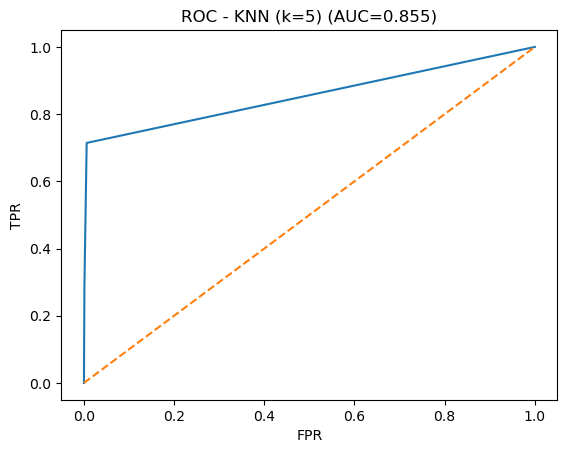

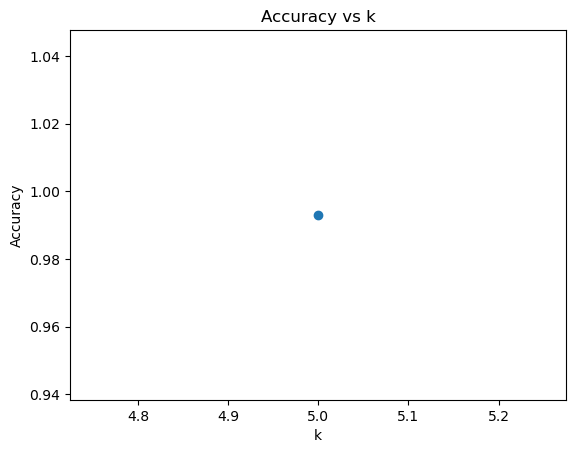

In [55]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

acc_knn5, auc_knn5 = evaluar(knn, X_test_scaled, y_test, "KNN (k=5)")

# Búsqueda de k
k_values = [5]
accs = []

for k in k_values:
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_train_scaled, y_train)
    y_pred = m.predict(X_test_scaled)
    accs.append(accuracy_score(y_test, y_pred))

plt.figure()
plt.plot(k_values, accs, marker="o")
plt.title("Accuracy vs k")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.show()



=== SVM RBF ===
Accuracy: 0.994
Matriz de confusión:
 [[993   0]
 [  6   1]]
Classification report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       993
           1       1.00      0.14      0.25         7

    accuracy                           0.99      1000
   macro avg       1.00      0.57      0.62      1000
weighted avg       0.99      0.99      0.99      1000



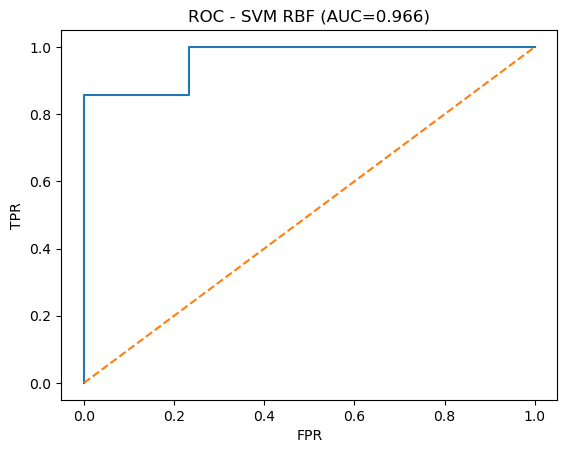

In [52]:
svm_rbf = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42)
svm_rbf.fit(X_train_scaled, y_train)
acc_svm_rbf, auc_svm_rbf = evaluar(svm_rbf, X_test_scaled, y_test, "SVM RBF")

## 7) ROC y AUC (comparación)

Dibuja la curva ROC de los 3 modelos en la misma gráfica y calcula su AUC.

Responde: 
Observando la ROC, ¿qué modelo mantiene mayor **TPR** para **FPR bajos** (por ejemplo 0–0,1) y por qué es relevante en medicina?
El modelo en base a las gráficas es el svm, pero nos interesa para la medicina ya que los datos de falsos negativos son muy importantes ya que no quedemos dar de alta a un paciente que no está sano o está desarrollando una enfermedad


In [ ]:
# 
#
# - Calcula (fpr, tpr) y AUC para cada modelo
# - Dibuja las 3 curvas ROC en la misma gráfica
# - Muestra una tabla con AUC por modelo


## 8) Ajuste de hiperparámetros (KNN)

Evalúa KNN para: `k = [1, 3, 5, 9, 15]` y representa **accuracy vs k**.

Responde:

- ¿Qué valores de k tienden a sobreajustar? 

Aunque sean los que menos valor tienen, cuantos mas vecinos busques, tiendes a sobreajustar mas ya que el modelo encuentra patrones de forma mas habitual,
por lo que podriamos decir que 9 y 15
- ¿Qué valores de k tienden a infraajustar?  

Los valores mas pequeños ya que con solo 1 vecino o incluso 3 no podemos sacar una conclusión para asegurar que nuestro modelo sea preciso
- Justifica usando el comportamiento del gráfico.



=== KNN (k=5) ===
Accuracy: 0.993
Matriz de confusión:
 [[993   0]
 [  7   0]]
Classification report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       993
           1       0.00      0.00      0.00         7

    accuracy                           0.99      1000
   macro avg       0.50      0.50      0.50      1000
weighted avg       0.99      0.99      0.99      1000



/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


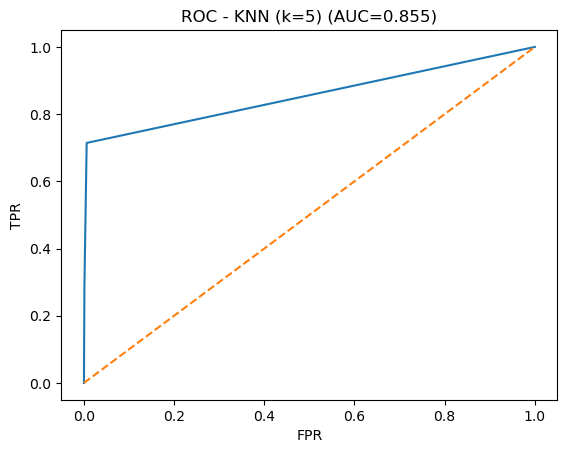

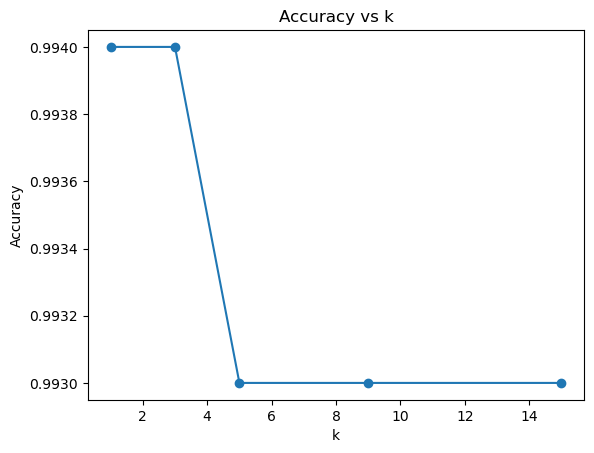

In [56]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

acc_knn5, auc_knn5 = evaluar(knn, X_test_scaled, y_test, "KNN (k=5)")

# Búsqueda de k
k_values = [1,3,5,9,15]
accs = []

for k in k_values:
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_train_scaled, y_train)
    y_pred = m.predict(X_test_scaled)
    accs.append(accuracy_score(y_test, y_pred))

plt.figure()
plt.plot(k_values, accs, marker="o")
plt.title("Accuracy vs k")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.show()


## 9) Ajuste de hiperparámetros (SVM RBF)

Prueba varias combinaciones de `C` y `gamma` y analiza su impacto.


1. Prueba al menos estas combinaciones:  
   - (C=0.1, gamma='scale')  
   - (C=1, gamma='scale')  
   - (C=10, gamma=0.1)  
2. Guarda accuracy y AUC en una tabla.

Responde:

- ¿Qué combinación parece más estable?  

La que utilizo con C=3 ya que es la que probablemente tiene un menor sobreajuste de los posibles datos que tenemos y saca menos falsos negativos

- ¿Detectas algún signo de sobreajuste? (explica por qué)

El unico signo de sobreajuste que se podría llegar a detectar es que el accuracy es muy alto, pero esto es problema de la distribución de los datos,
ya que tenemos muchos datos que no son nota alta, por lo que al modelo no le cuesta tanto predecirlo, es probable que los errores estén en el baremo justo que 
divide ambas categorias.


SVM RBF1
Accuracy: 0.994

Classification report:
              precision    recall  f1-score   support

           0      0.994     1.000     0.997       993
           1      1.000     0.143     0.250         7

    accuracy                          0.994      1000
   macro avg      0.997     0.571     0.623      1000
weighted avg      0.994     0.994     0.992      1000



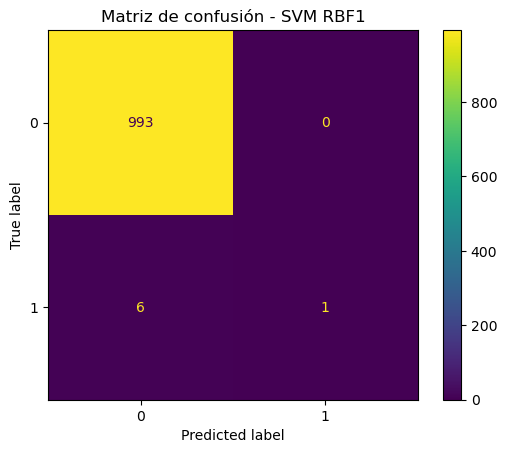

SVM RBF2
Accuracy: 0.996

Classification report:
              precision    recall  f1-score   support

           0      0.996     1.000     0.998       993
           1      1.000     0.429     0.600         7

    accuracy                          0.996      1000
   macro avg      0.998     0.714     0.799      1000
weighted avg      0.996     0.996     0.995      1000



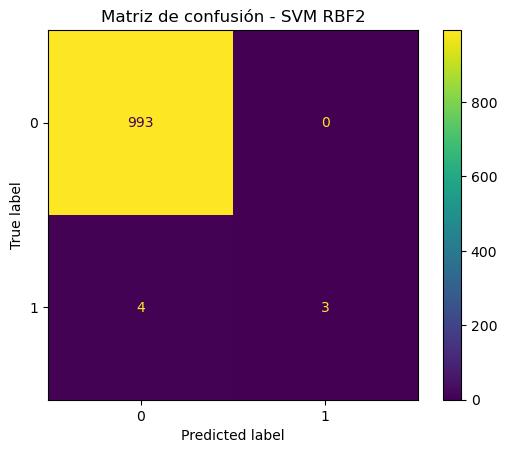

SVM RBF3
Accuracy: 0.996

Classification report:
              precision    recall  f1-score   support

           0      0.996     1.000     0.998       993
           1      1.000     0.429     0.600         7

    accuracy                          0.996      1000
   macro avg      0.998     0.714     0.799      1000
weighted avg      0.996     0.996     0.995      1000



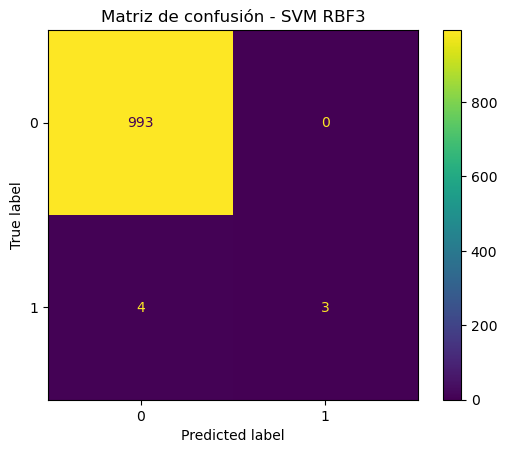

SVM RBF4
Accuracy: 0.996

Classification report:
              precision    recall  f1-score   support

           0      0.996     1.000     0.998       993
           1      1.000     0.429     0.600         7

    accuracy                          0.996      1000
   macro avg      0.998     0.714     0.799      1000
weighted avg      0.996     0.996     0.995      1000



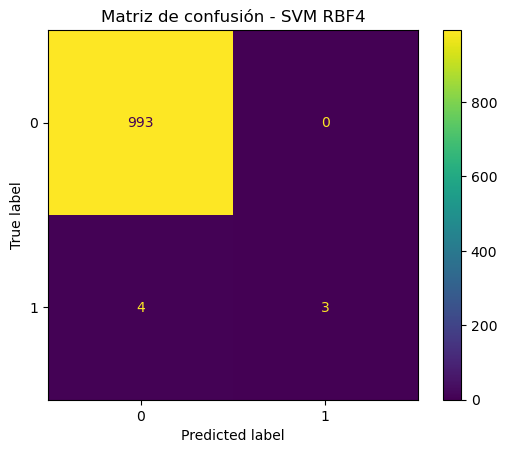

SVM RBF5
Accuracy: 0.996

Classification report:
              precision    recall  f1-score   support

           0      0.996     1.000     0.998       993
           1      1.000     0.429     0.600         7

    accuracy                          0.996      1000
   macro avg      0.998     0.714     0.799      1000
weighted avg      0.996     0.996     0.995      1000



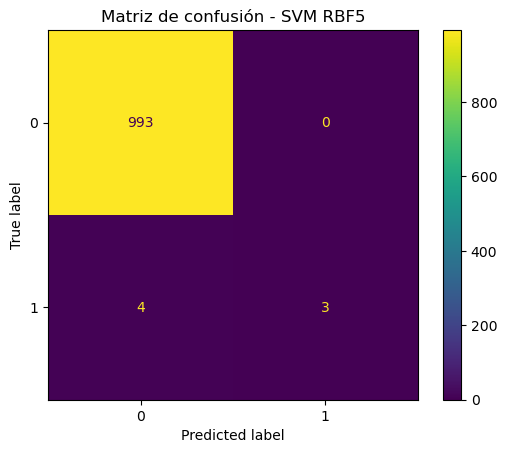

,Accuracy
SVM RBF2,0.996
SVM RBF4,0.996
SVM RBF3,0.996
SVM RBF5,0.996
SVM RBF1,0.994


In [59]:
# 5) Modelos
modelos = {
    "SVM RBF1": SVC(kernel="rbf", C=1, gamma="scale", random_state=42),
    "SVM RBF2": SVC(kernel="rbf", C=3, gamma="scale", random_state=42),
    "SVM RBF3": SVC(kernel="rbf", C=5, gamma="scale", random_state=42),
    "SVM RBF4": SVC(kernel="rbf", C=9, gamma="scale", random_state=42),
    "SVM RBF5": SVC(kernel="rbf", C=15, gamma="scale", random_state=42),
}


# 6) Entrenamiento + evaluación
resultados = {}

for nombre, modelo in modelos.items():
    modelo.fit(X_train_scaled, y_train)
    y_pred = modelo.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    resultados[nombre] = acc

    print("="*70)
    print(nombre)
    print(f"Accuracy: {acc:.3f}\n")
    print("Classification report:")
    print(classification_report(y_test, y_pred, digits=3))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {nombre}")
    plt.show()

resultados_df = pd.DataFrame.from_dict(resultados, orient="index", columns=["Accuracy"]).sort_values("Accuracy", ascending=False)
resultados_df



## 10) Cuestiones

Redacta una conclusión breve que incluya:

1. Qué modelo elegirías como “mejor” y por qué (menciona al menos 2 evidencias: ROC/AUC, matriz de confusión, estabilidad al ajustar).
Ante la evidencia de accuracy altos de mas de 0,95 en estos modelos debido al desajuste de datos, elegiría el modelo de svm, debido a que los resultados de las 
graficas de ROC y AUC son bastante mas óptimos que el KNN, y que a la hora de incrementar el dataset con más datos, podremos reajustarlo para optimizar el modelo y que la
matriz de confusión nos salga mejor, en cambio el KNN y la regresión logistica a la hora de enfrentar a un modelo mayor, acabarían sufriendo mucho más y empeorarían el resultado.

2. Si tu objetivo fuera **minimizar falsos negativos**, ¿qué modelo preferirías y por qué?  
Me quedaría con el SVM ya que al poder ajustar los datos, como hemos visto anteriormente en el ejercicio, hemos podido minimizar los falsos negativos de 6 a 4, haciendo que mejore la precisión incluso.

